In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load your data from a CSV file
df = pd.read_csv('/content/fresher_hiring_india_dataset.csv')

In [ ]:
print(df.isnull().sum())
print(df.shape)
print(df.columns.to_list())

candidate_id                 0
full_name                    0
gender                       0
age                          0
graduation_year              0
college                      0
degree                       0
branch                       0
cgpa                         0
backlogs                     0
gap_year                     0
prior_internship             0
projects_count               0
certifications_count         0
top_skills                   0
platform                     0
company_applied              0
sector                       0
job_role                     0
work_type                    0
job_location                 0
application_date             0
hiring_stage                 0
interview_rounds          3182
response_time_days           0
offered_salary_inr        4378
linkedin_connections         0
profile_completion_pct       0
linkedin_premium          3901
referral_applied             0
dtype: int64
(5000, 30)
['candidate_id', 'full_name', 'gender', 'age',

In [ ]:
def null_percentage(data):

    null_pct = data.isnull().mean() * 100
    return null_pct.sort_values(ascending=False)

In [ ]:
null_pct_series = null_percentage(df)
null_pct_series

,0
offered_salary_inr,87.56
linkedin_premium,78.02
interview_rounds,63.64
gender,0.00
candidate_id,0.00
full_name,0.00
degree,0.00
branch,0.00
cgpa,0.00
backlogs,0.00


In [ ]:
df.drop(columns=['interview_rounds', 'offered_salary_inr', 'linkedin_premium'], inplace=True)

In [ ]:
print(df.isnull().sum())
print(df.shape)
print(df.columns.to_list)
print(df.duplicated().sum())

candidate_id              0
full_name                 0
gender                    0
age                       0
graduation_year           0
college                   0
degree                    0
branch                    0
cgpa                      0
backlogs                  0
gap_year                  0
prior_internship          0
projects_count            0
certifications_count      0
top_skills                0
platform                  0
company_applied           0
sector                    0
job_role                  0
work_type                 0
job_location              0
application_date          0
hiring_stage              0
response_time_days        0
linkedin_connections      0
profile_completion_pct    0
referral_applied          0
dtype: int64
(5000, 27)
<bound method IndexOpsMixin.tolist of Index(['candidate_id', 'full_name', 'gender', 'age', 'graduation_year',
       'college', 'degree', 'branch', 'cgpa', 'backlogs', 'gap_year',
       'prior_internship', 'projects_cou

In [ ]:
df.head(3)

,candidate_id,full_name,gender,age,graduation_year,college,degree,branch,cgpa,backlogs,...,sector,job_role,work_type,job_location,application_date,hiring_stage,response_time_days,linkedin_connections,profile_completion_pct,referral_applied
0,1,Deepika Shukla,Female,23,2021,BITS Goa,B.E.,Electrical,5.89,3,...,EdTech,QA Engineer,Internship,Bengaluru,2021-11-23,Technical Interview,22,1188,64,No
1,2,Piyush Reddy,Male,25,2022,IIEST Shibpur,B.Sc (IT),Information Technology,8.78,0,...,FinTech,Product Manager,Contract,Ahmedabad,2021-07-26,Shortlisted,30,2653,78,No
2,3,Itisha Arora,Female,21,2024,BIT Mesra Ranchi,BCA,Computer Applications,6.24,3,...,FinTech,HR Executive,Full-time,Delhi NCR,2022-03-09,Rejected,37,2990,75,No


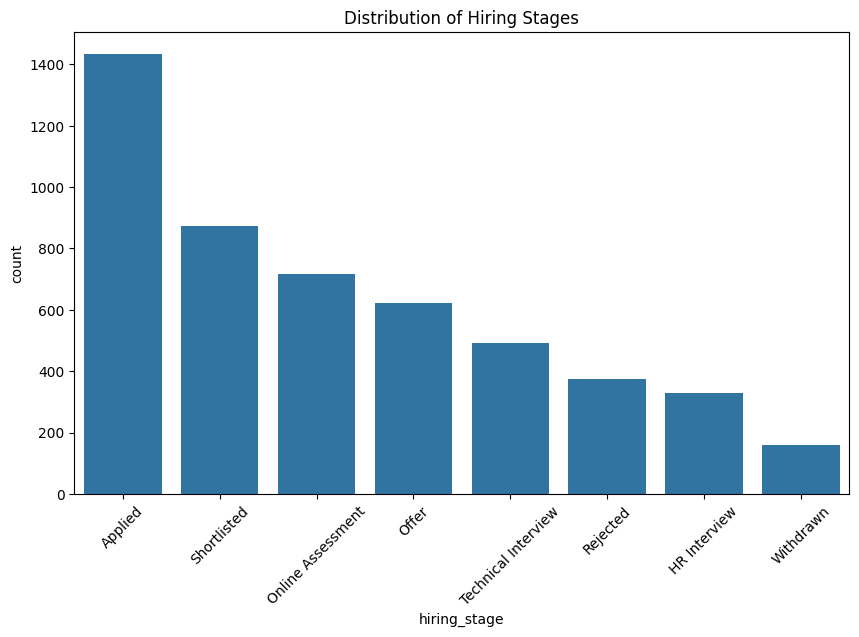

In [ ]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='hiring_stage',order=df['hiring_stage'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Distribution of Hiring Stages')
plt.show()

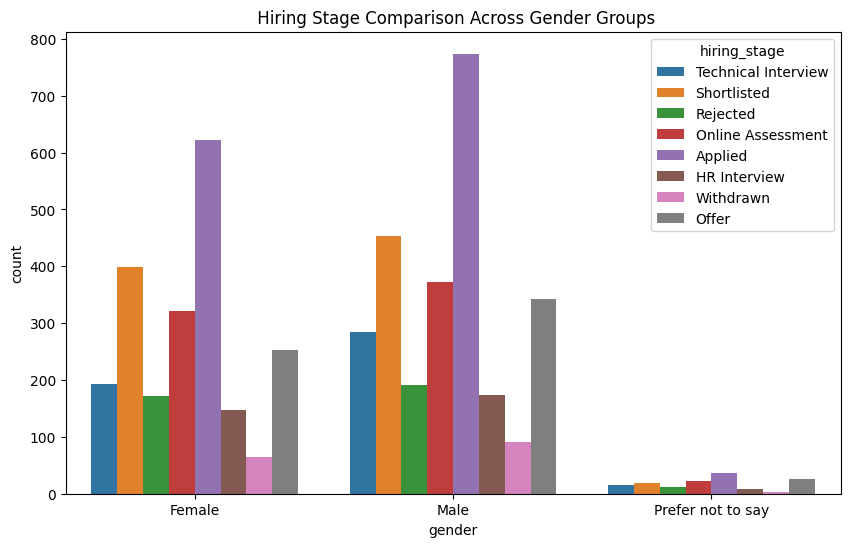

In [ ]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='gender', hue='hiring_stage')
plt.title(' Hiring Stage Comparison Across Gender Groups')
plt.show()

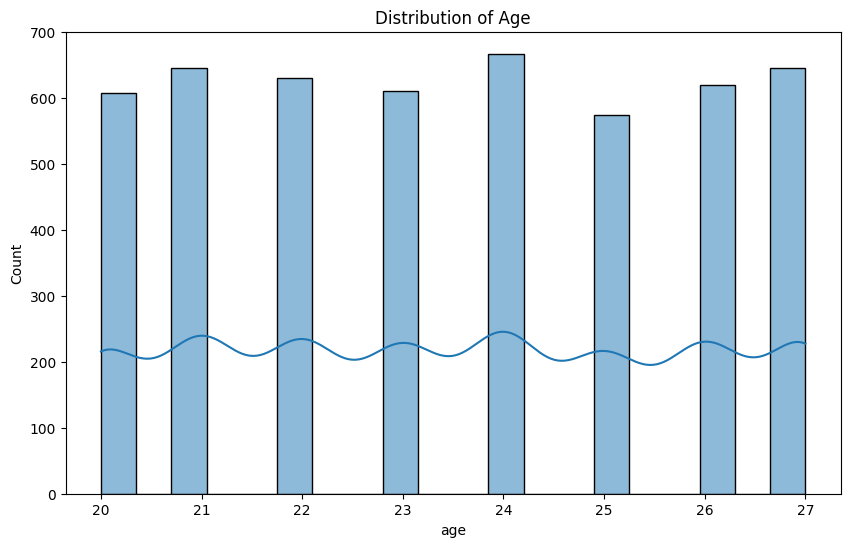

In [ ]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='age', bins=20, kde=True)
plt.title('Distribution of Age')
plt.show()

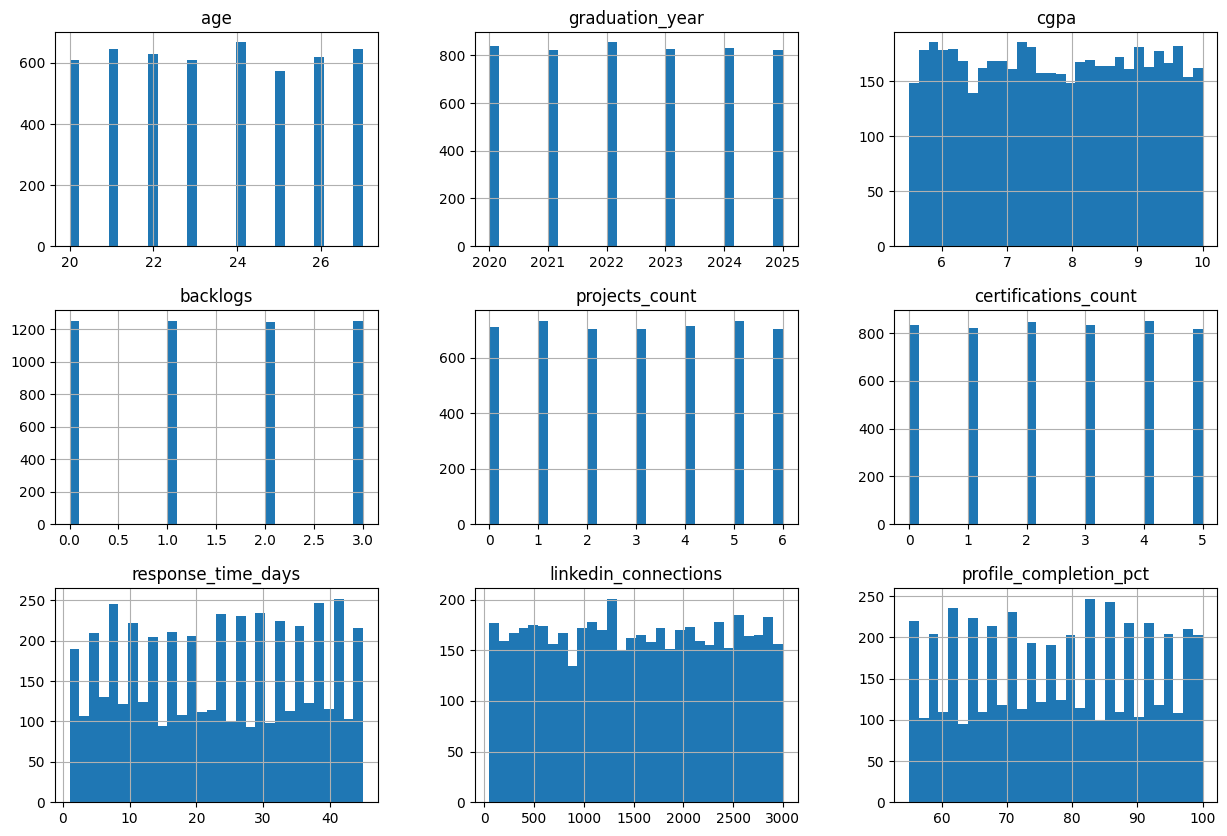

In [ ]:
num_features = ['age', 'graduation_year', 'cgpa', 'backlogs', 'projects_count',
                'certifications_count', 'response_time_days', 'linkedin_connections',
                'profile_completion_pct']
df[num_features].hist(bins=30, figsize=(15,10))
plt.show()

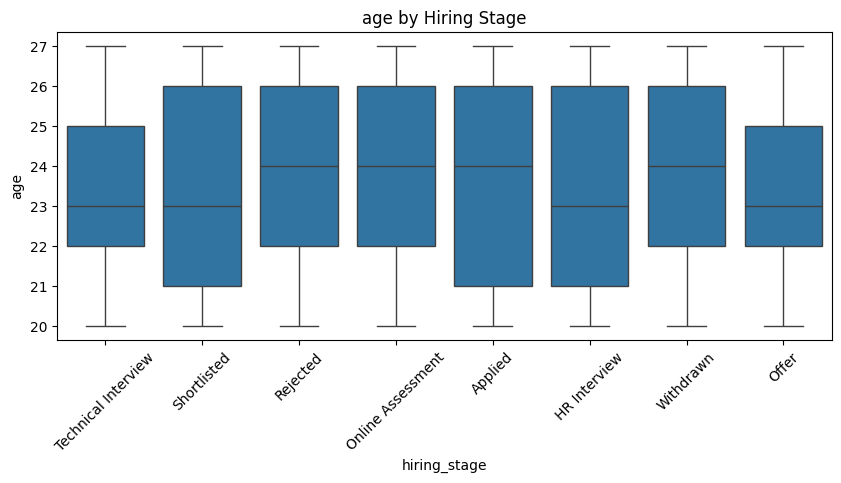

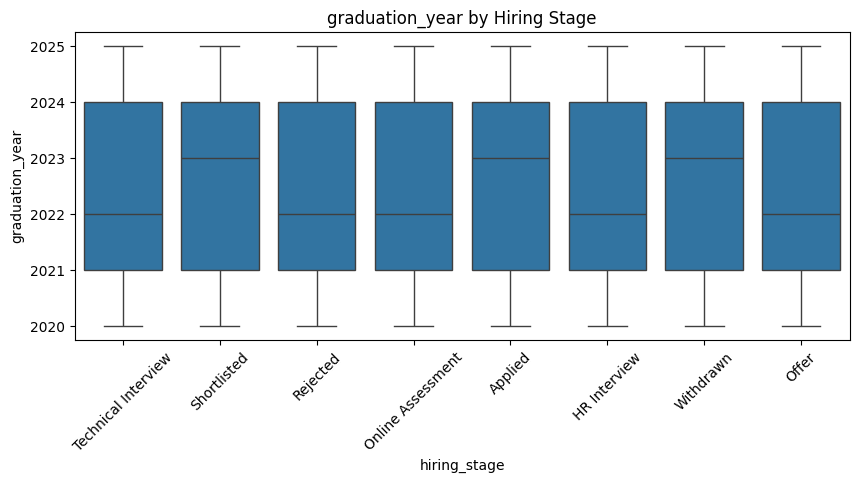

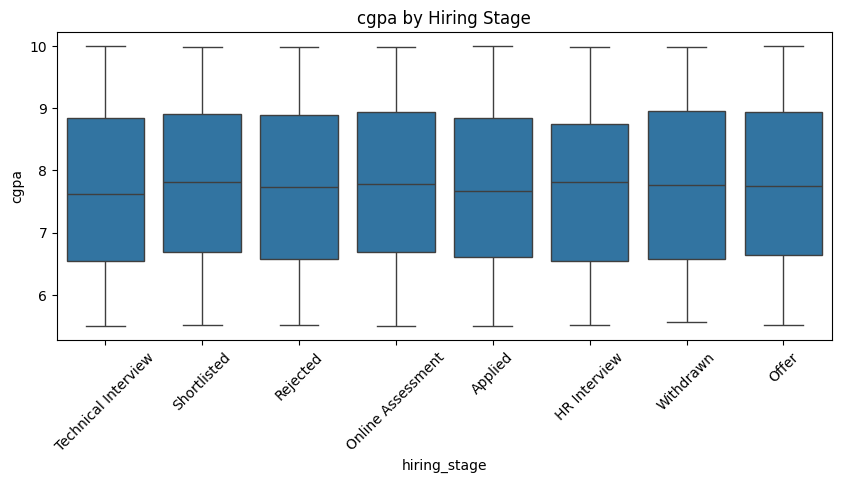

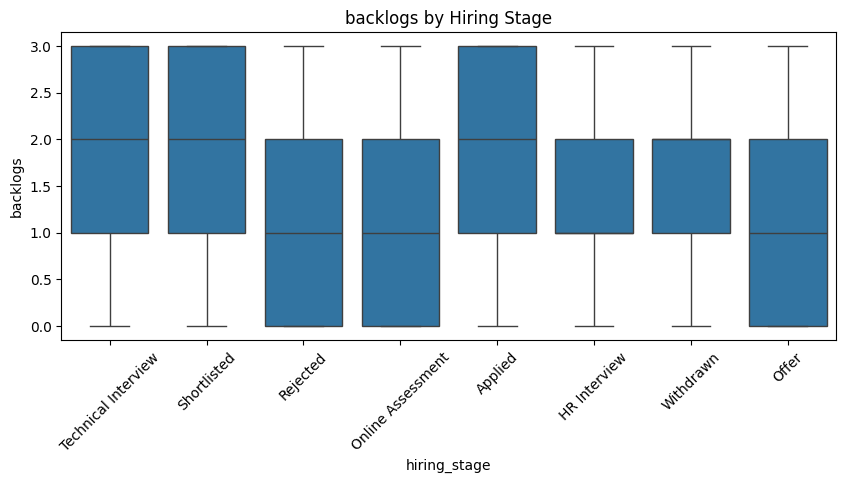

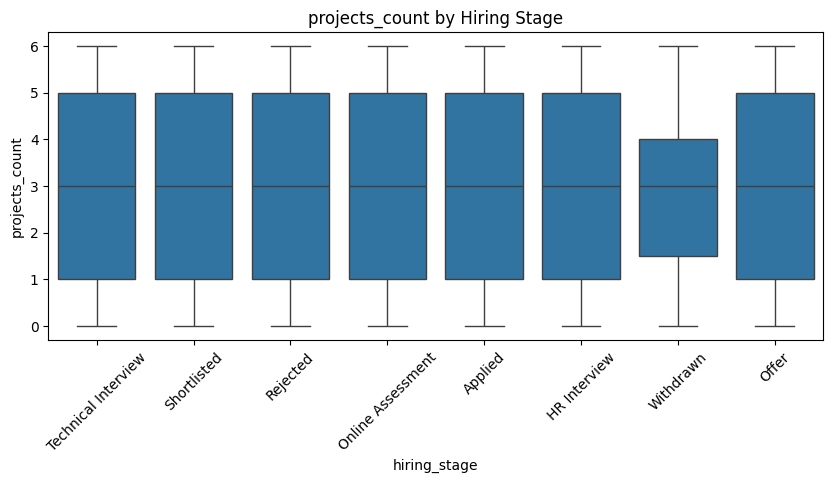

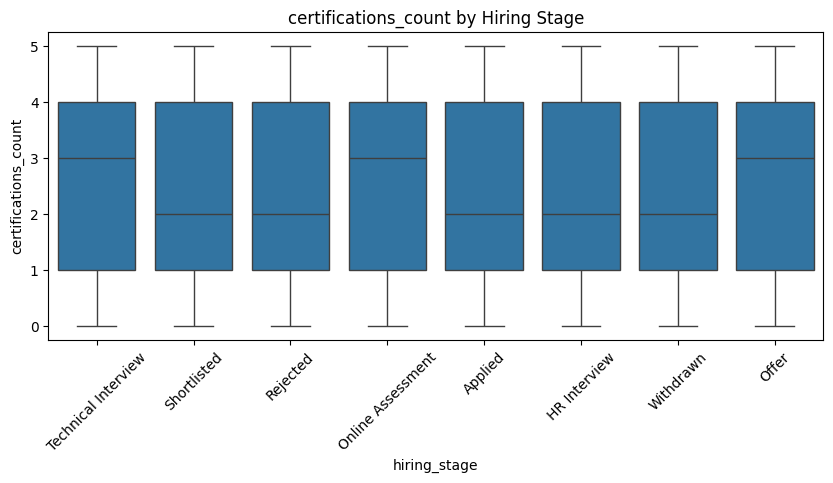

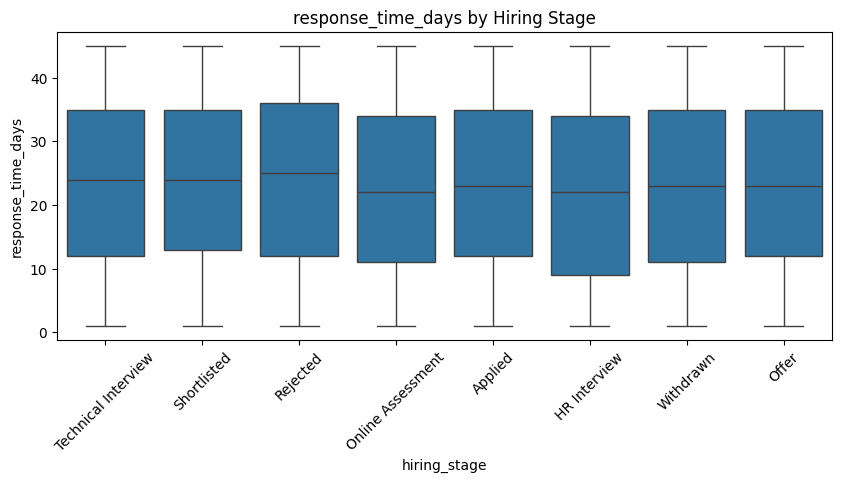

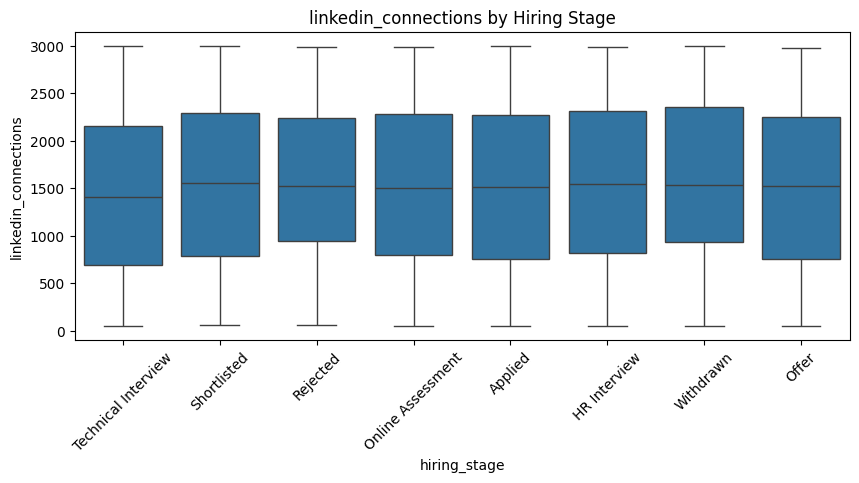

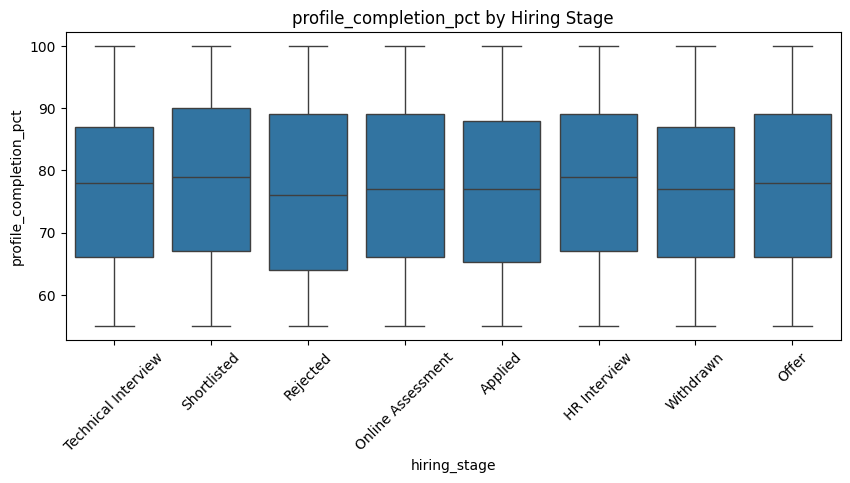

In [ ]:
for col in num_features:
    plt.figure(figsize=(10,4))
    sns.boxplot(data=df, x='hiring_stage', y=col)
    plt.xticks(rotation=45)
    plt.title(f'{col} by Hiring Stage')
    plt.show()

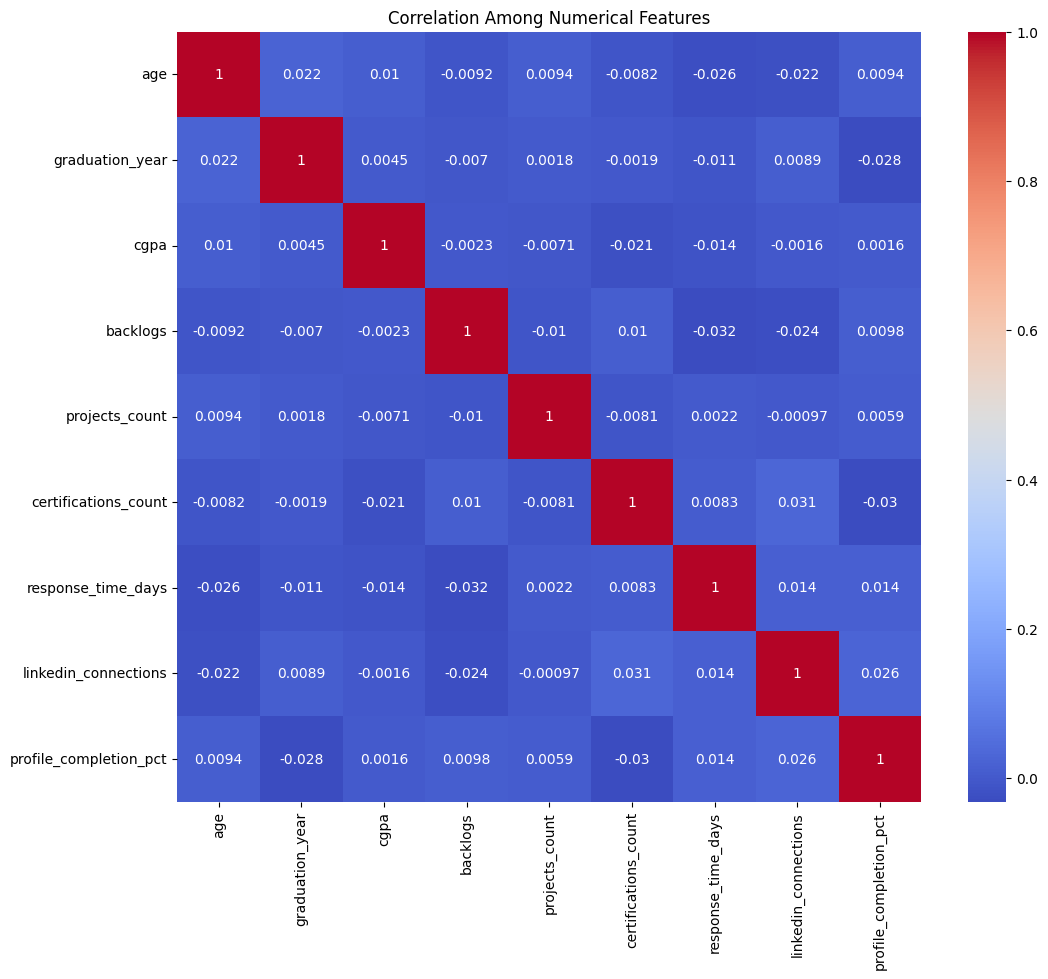

In [ ]:
plt.figure(figsize=(12,10))
# df.select_dtypes(include='number').corr() also can be used for num features correlation
sns.heatmap(df[num_features].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Among Numerical Features')
plt.show()

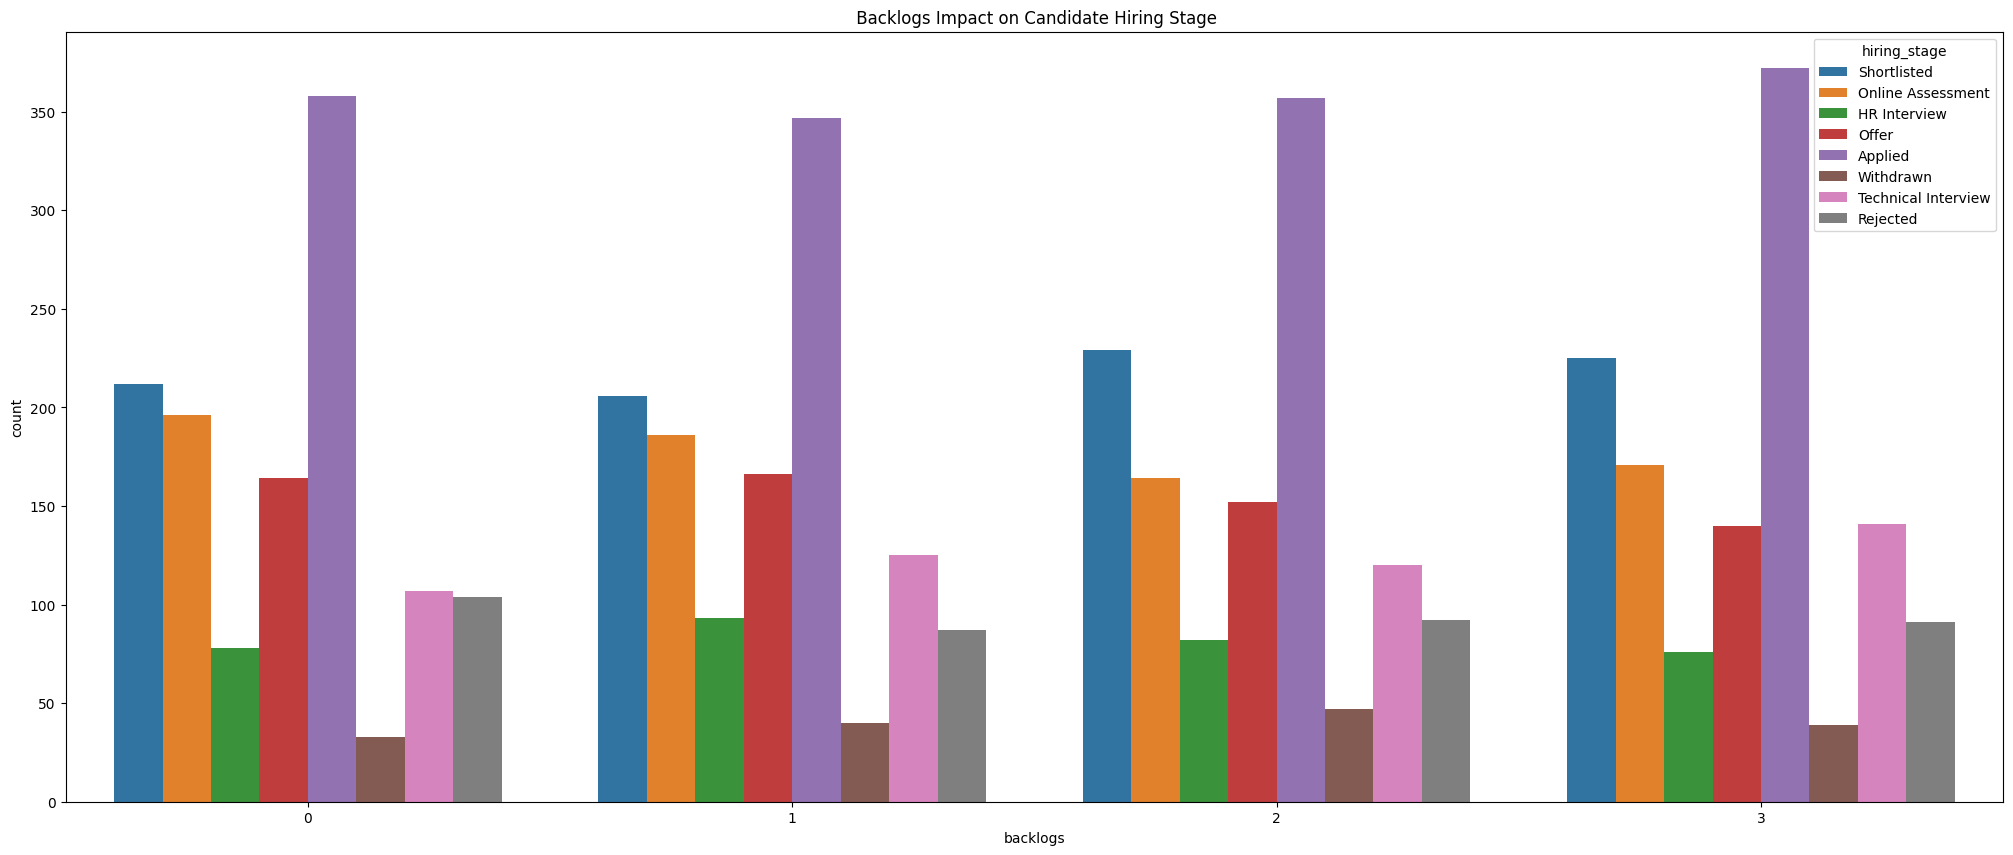

In [ ]:
fig = plt.figure(figsize=(25,10))
sns.countplot(data=df, x='backlogs', hue='hiring_stage')
plt.title(' Backlogs Impact on Candidate Hiring Stage')
plt.show()

In [ ]:
# Label encode binary / ordinal columns
binary_cols = ['gender', 'gap_year', 'prior_internship', 'referral_applied']
le_dict = {}
for col in binary_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# For multi‑category columns, use one‑hot encoding
multi_cat = ['college', 'degree', 'branch', 'top_skills', 'platform',
             'company_applied', 'sector', 'job_role', 'work_type', 'job_location']
df_encoded = pd.get_dummies(df, columns=multi_cat, drop_first=True)

In [ ]:
df['skill_count'] = df['top_skills'].str.count('|') + 1
df.head(3)

,candidate_id,full_name,gender,age,graduation_year,college,degree,branch,cgpa,backlogs,...,job_role,work_type,job_location,application_date,hiring_stage,response_time_days,linkedin_connections,profile_completion_pct,referral_applied,skill_count
0,1,Deepika Shukla,0,23,2021,BITS Goa,B.E.,Electrical,5.89,3,...,QA Engineer,Internship,Bengaluru,2021-11-23,Technical Interview,22,1188,64,0,31
1,2,Piyush Reddy,1,25,2022,IIEST Shibpur,B.Sc (IT),Information Technology,8.78,0,...,Product Manager,Contract,Ahmedabad,2021-07-26,Shortlisted,30,2653,78,0,53
2,3,Itisha Arora,0,21,2024,BIT Mesra Ranchi,BCA,Computer Applications,6.24,3,...,HR Executive,Full-time,Delhi NCR,2022-03-09,Rejected,37,2990,75,0,27


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import numpy as np # Import numpy for np.number

# Separate features and target
# X = df_encoded.drop(['hiring_stage', 'full_name', 'candidate_id', 'application_date'], axis=1)
y = df_encoded['hiring_stage']

# This will make ensure X only contains numerical features
# This will drop any remaining non-numeric columns, preventing the ValueError
X = X.select_dtypes(include=np.number)

# Encode target (if not already numeric)
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

Accuracy: 0.258
                     precision    recall  f1-score   support

            Applied       0.29      0.78      0.42       287
       HR Interview       0.00      0.00      0.00        66
              Offer       0.24      0.06      0.09       124
  Online Assessment       0.12      0.04      0.06       143
           Rejected       0.00      0.00      0.00        75
        Shortlisted       0.15      0.11      0.13       174
Technical Interview       0.10      0.01      0.02        99
          Withdrawn       0.00      0.00      0.00        32

           accuracy                           0.26      1000
          macro avg       0.11      0.13      0.09      1000
       weighted avg       0.17      0.26      0.17      1000



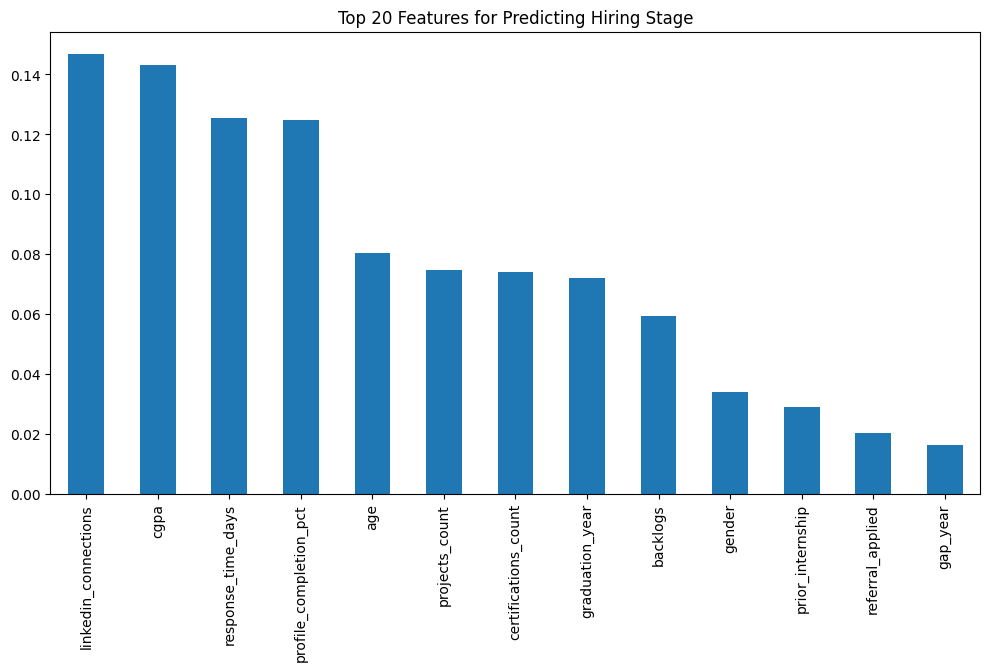

In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(12,6))
importances.head(20).plot(kind='bar')
plt.title('Top 20 Features for Predicting Hiring Stage')
plt.show()

In [ ]:
# Example: Platform vs Offer rate
platform_offer = df[df['hiring_stage']=='Offer']['platform'].value_counts(normalize=True)
print(platform_offer)

platform
LinkedIn            0.225080
Naukri              0.189711
Indeed              0.102894
Internshala         0.091640
Referral            0.062701
Campus Placement    0.057878
Unstop              0.051447
Cutshort            0.049839
AngelList           0.045016
HackerEarth         0.040193
Glassdoor           0.022508
Monster             0.016077
WorkIndia           0.008039
Apna                0.008039
Hirist              0.006431
Shine               0.006431
Foundit             0.004823
Freshersworld       0.004823
TimesJobs           0.003215
IIMJobs             0.003215
Name: proportion, dtype: float64


In [ ]:
import joblib

joblib.dump(rf, 'model.pkl')
joblib.dump(le_target, 'label_encoder.pkl')

['label_encoder.pkl']